ПЕРВИЧНЫЙ ОБЗОР ДАТАСЕТА
Размер данных: 22676 строк, 12 столбцов

Первые 5 строк:
        Price Apartment type Metro station  Minutes to metro         Region  \
0  6300000.00      Secondary       Опалиха              6.00  Moscow region   
1  9000000.00      Secondary       Павшино              2.00  Moscow region   
2 11090000.00      Secondary      Мякинино             14.00  Moscow region   
3  8300000.00      Secondary      Строгино              8.00  Moscow region   
4  6450000.00      Secondary       Опалиха              6.00  Moscow region   

   Number of rooms  Area  Living area  Kitchen area  Floor  Number of floors  \
0             1.00 30.60        11.10          8.50  25.00                25   
1             1.00 49.20        20.00         10.00   6.00                15   
2             1.00 44.70        16.20         13.10  10.00                25   
3             1.00 35.10        16.00         11.00  12.00                33   
4             1.00 37.70        15.20      

C:\Users\1\AppData\Local\Temp\ipykernel_23972\3891528203.py:49: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


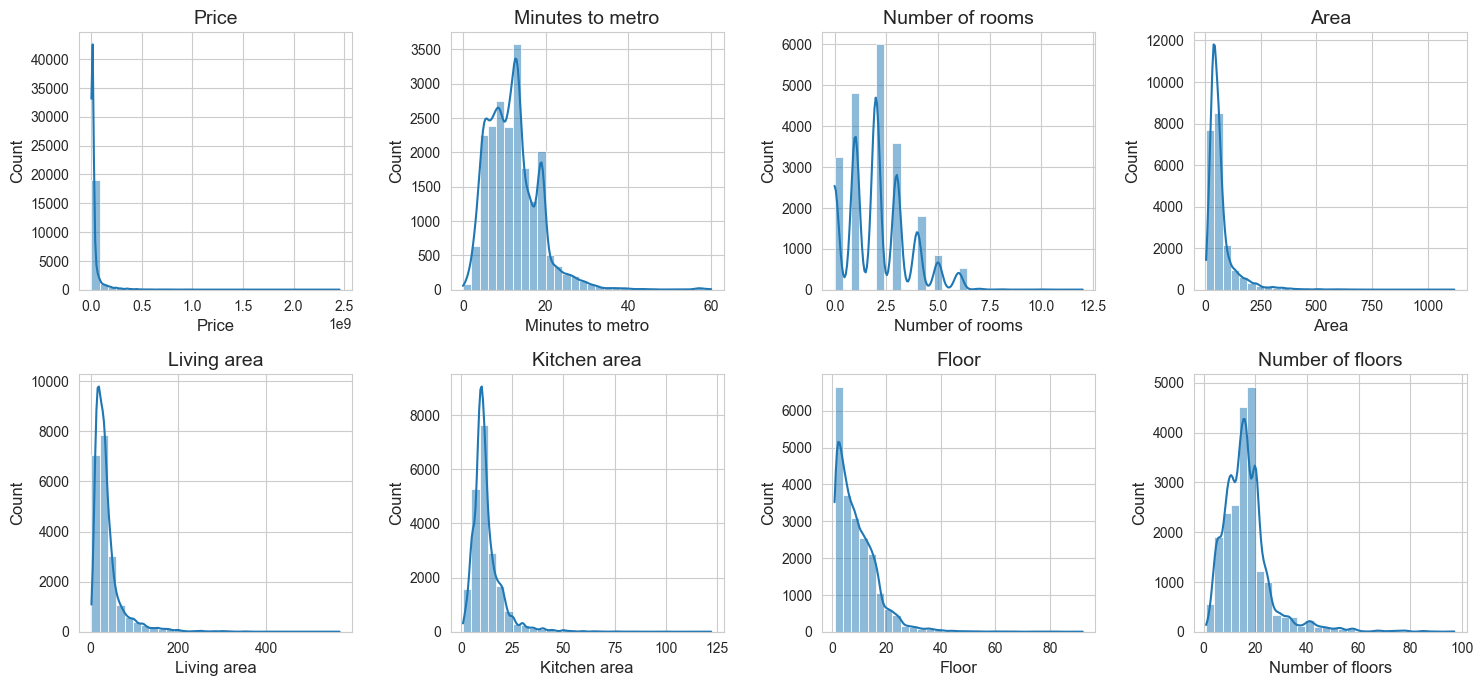


Очищенный датасет сохранён как 'data_cleaned.csv'

КОРРЕЛЯЦИЯ МЕЖДУ ЧИСЛОВЫМИ ПРИЗНАКАМИ


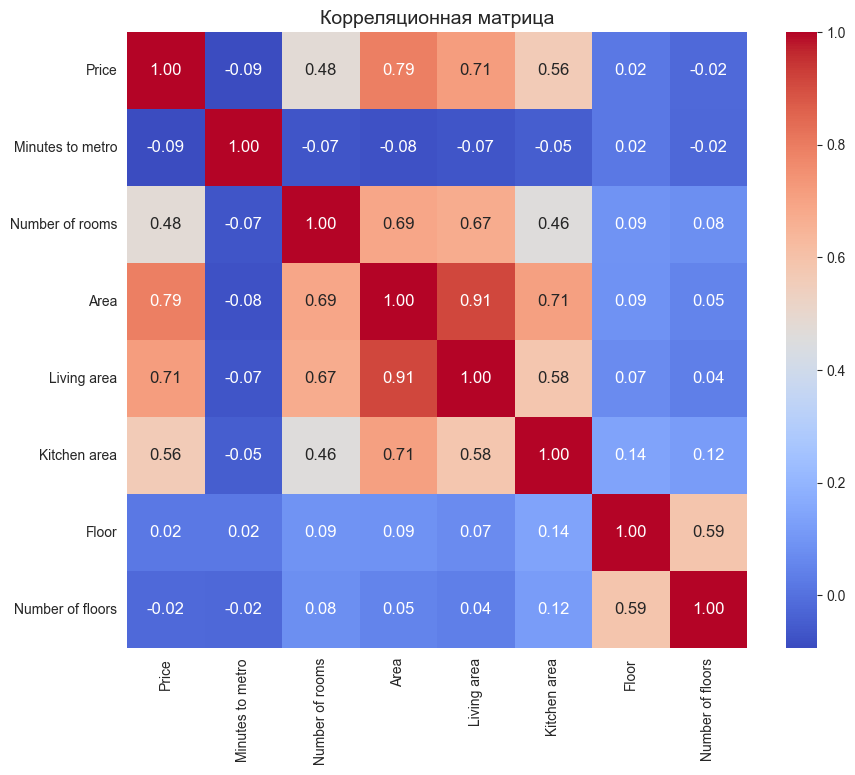

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# 1. Загрузка данных
df = pd.read_csv('data.csv')  # укажи свой путь к файлу

print("="*50)
print("ПЕРВИЧНЫЙ ОБЗОР ДАТАСЕТА")
print("="*50)
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов\n")

print("Первые 5 строк:")
print(df.head(), "\n")

print("Информация о столбцах и типах:")
print(df.info(), "\n")

print("Статистическое описание числовых признаков:")
print(df.describe(include=[np.number]), "\n")

# 2. Проверка на пропуски
print("="*50)
print("ПРОВЕРКА НА ПРОПУСКИ")
print("="*50)
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_table = pd.DataFrame({'Пропуски': missing, 'Доля %': missing_percent})
print(missing_table[missing_table['Пропуски'] > 0], "\n")

# 3. Проверка на дубликаты
duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates}\n")

# 4. Удаление или заполнение пропусков
print("="*50)
print("ОБРАБОТКА ПРОПУСКОВ")
print("="*50)

# Выбор стратегии: можно удалить все строки с пропусками (если их немного)
# Или заполнить пропуски для разных типов столбцов.

# Предварительно посмотрим, какие столбцы какие
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Категориальные столбцы:", categorical_cols)
print("Числовые столбцы:", numeric_cols, "\n")

# Вариант 1: удаление всех строк с любым пропуском (просто, но может потерять данные)
# df_clean = df.dropna()

# Вариант 2: интеллектуальное заполнение (рекомендую)
df_clean = df.copy()

for col in categorical_cols:
    if df_clean[col].isnull().any():
        # Заполняем самой частой категорией (мода)
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Заполнены пропуски в '{col}' модой: {mode_val}")

for col in numeric_cols:
    if df_clean[col].isnull().any():
        # Заполняем медианой (устойчива к выбросам)
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Заполнены пропуски в '{col}' медианой: {median_val}")

print("\nПроверка пропусков после заполнения:")
print(df_clean.isnull().sum().sum(), "пропусков осталось.\n")

# Можно также удалить строки, где пропуски остались (если есть)
# df_clean.dropna(inplace=True)

# 6. Проверка дубликатов после очистки
df_clean.drop_duplicates(inplace=True)
print(f"После удаления дубликатов: {df_clean.shape[0]} строк")

# 7. Базовый анализ выбросов (визуально)
print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*50)

plt.figure(figsize=(15, 10))
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 4, i)  # подбери размер сетки под своё количество
    sns.histplot(df_clean[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# 8. Сохранение очищенного датасета
df_clean.to_csv('data_cleaned.csv', index=False)
print("\nОчищенный датасет сохранён как 'data_cleaned.csv'")

# 9. Дополнительно: корреляционная матрица (если интересно)
print("\n" + "="*50)
print("КОРРЕЛЯЦИЯ МЕЖДУ ЧИСЛОВЫМИ ПРИЗНАКАМИ")
print("="*50)
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Загружаем очищенный датасет (после предыдущей обработки)
# Если у тебя данные уже в переменной df_clean, можно пропустить загрузку
df = pd.read_csv('data_cleaned.csv')

print("Размер данных:", df.shape)
print("\nПервые строки:")
print(df.head())

# 1. Определяем целевой признак
target = 'Price'  # предположим, что столбец называется именно так (скорректируй при необходимости)
X = df.drop(columns=[target])
y = df[target]

# 2. Разделяем на категориальные и числовые признаки
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nКатегориальные признаки: {categorical_cols}")
print(f"Числовые признаки: {numeric_cols}")

# 3. Создаём предобработчик
# Для категориальных: OneHotEncoding (drop='first' чтобы избежать дамми-ловушки)
# Для числовых: стандартизация
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# 4. Разделяем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# 5. Создаём пайплайны для разных моделей

# 5.1 Обычная линейная регрессия
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 5.2 Ridge регрессия (L2-регуляризация) с подбором alpha
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])
ridge_params = {'regressor__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}

# 5.3 Lasso регрессия (L1-регуляризация) с подбором alpha
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=10000))
])
lasso_params = {'regressor__alpha': [0.01, 0.1, 1.0, 5.0, 10.0]}

# 6. Обучаем модели и оцениваем

models = {
    'Linear Regression': (lr_pipeline, {}),
    'Ridge': (ridge_pipeline, ridge_params),
    'Lasso': (lasso_pipeline, lasso_params)
}

results = {}

for name, (pipeline, params) in models.items():
    print(f"\n{'='*50}")
    print(f"Обучение: {name}")
    
    if params:
        # Поиск по сетке с кросс-валидацией (5 фолдов)
        grid = GridSearchCV(pipeline, params, cv=5, scoring='r2', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"Лучшие гиперпараметры: {grid.best_params_}")
    else:
        best_model = pipeline.fit(X_train, y_train)
    
    # Предсказания на тесте
    y_pred = best_model.predict(X_test)
    
    # Метрики
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Кросс-валидация на обучающей выборке
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'model': best_model,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'CV_mean': cv_scores.mean(),
        'CV_std': cv_scores.std()
    }
    
    print(f"R² на тесте: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"CV R² (среднее ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# 7. Сравнение моделей
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'R²': [results[m]['R2'] for m in results],
    'MAE': [results[m]['MAE'] for m in results],
    'RMSE': [results[m]['RMSE'] for m in results],
    'CV R²': [results[m]['CV_mean'] for m in results]
})
print(comparison.to_string(index=False))

# 8. Анализ коэффициентов лучшей модели (выберем модель с наивысшим R²)
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = results[best_model_name]['model']
print(f"\nЛучшая модель: {best_model_name}")

# Получаем имена признаков после предобработки
# Для этого нужно применить препроцессор к небольшому фрейму и получить имена
# Сложность: ColumnTransformer не хранит имена автоматически.
# Можно получить их вручную:
preprocessor_fitted = best_model.named_steps['preprocessor']
# Числовые имена
num_features = numeric_cols
# Категориальные имена (после one-hot)
cat_encoder = preprocessor_fitted.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([num_features, cat_feature_names])

# Коэффициенты
coefs = best_model.named_steps['regressor'].coef_
# Для Lasso/Ridge коэффициенты могут быть обнулены
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefs
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nТоп-10 наиболее влиятельных признаков (по модулю коэффициента):")
print(feature_importance.head(10).to_string(index=False))

# 9. Визуализация предсказаний vs реальных значений для лучшей модели
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title(f'Предсказание vs Реальность (лучшая модель: {best_model_name})\nR² = {results[best_model_name]["R2"]:.4f}')
plt.grid(True)
plt.show()

# 10. (Опционально) Сохраняем лучшую модель с помощью joblib
# from joblib import dump
# dump(best_model, 'best_model.joblib')
# print("Модель сохранена в best_model.joblib")

Размер данных: (20841, 12)

Первые строки:
        Price Apartment type Metro station  Minutes to metro         Region  \
0  6300000.00      Secondary       Опалиха              6.00  Moscow region   
1  9000000.00      Secondary       Павшино              2.00  Moscow region   
2 11090000.00      Secondary      Мякинино             14.00  Moscow region   
3  8300000.00      Secondary      Строгино              8.00  Moscow region   
4  6450000.00      Secondary       Опалиха              6.00  Moscow region   

   Number of rooms  Area  Living area  Kitchen area  Floor  Number of floors  \
0             1.00 30.60        11.10          8.50  25.00                25   
1             1.00 49.20        20.00         10.00   6.00                15   
2             1.00 44.70        16.20         13.10  10.00                25   
3             1.00 35.10        16.00         11.00  12.00                33   
4             1.00 37.70        15.20          4.00   5.00                 5   

 

C:\Users\1\AppData\Local\Temp\ipykernel_23972\3766279651.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarn

R² на тесте: 0.7027
MAE: 15933027.41
RMSE: 40594072.97
CV R² (среднее ± std): 0.7078 ± 0.0189

Обучение: Ridge
Лучшие гиперпараметры: {'regressor__alpha': 1.0}


C:\Users\1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown ca

R² на тесте: 0.7047
MAE: 15900211.12
RMSE: 40455066.20
CV R² (среднее ± std): 0.7121 ± 0.0196

Обучение: Lasso


KeyboardInterrupt: 